In [4]:

from typing import Annotated
from typing_extensions import TypedDict
from langchain_groq import ChatGroq
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
import os
from dotenv import load_dotenv
from IPython.display import Image,display
load_dotenv()

True

In [5]:
os.environ["GROQ_API_KEY"]= os.getenv("GROQ_API_KEY") #type:ignore
os.environ["LANGSMITH_API_KEY"]= os.getenv("LANGSMITH_API_KEY") #type:ignore
os.environ["LANGSMITH_TRACING"]="true"
os.environ["LANGSMITH_PROJECT"]="jayendra"
os.environ["LANGSMITH_ENDPOINT"]="https://api.smith.langchain.com"


In [6]:
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:openai/gpt-oss-120b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.17'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B5A307EF90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B5A307FA10>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
class State(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [8]:
## graph with tool call 
from langchain_core.tools import tool

@tool 
def add(a:float,b:float):
    """Add two number"""
    
    return a+b

tools = [add]
llm_with_tool = llm.bind_tools([add])

def call_llm_model(state:State): #type:ignore
    return {"messages":[llm_with_tool.invoke(state['messages'])]} #type:ignore

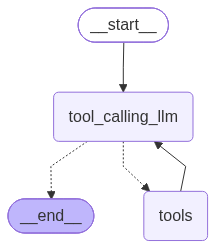

In [9]:
## StateGraph

builder = StateGraph(State)
builder.add_node("tool_calling_llm", call_llm_model)
builder.add_node("tools",ToolNode(tools))

#edge
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
response = graph.invoke({"messages":"What is machine learning"}) #type:ignore

In [11]:
response['messages'][-1].content

'**Machine learning (ML)** is a sub‑field of artificial intelligence that focuses on building systems that can learn from data rather than being explicitly programmed for every possible situation. In other words, instead of writing step‑by‑step rules for a task, we give a computer a large collection of examples (the *training data*) and let it discover patterns, relationships, or decision rules that let it perform the task on new, unseen data.\n\n---\n\n## Core Idea\n\n1. **Data → Model → Prediction**  \n   - **Data**: A set of examples, each with input features (e.g., pixels, sensor readings, text) and often a target label (e.g., “cat” vs. “dog”).  \n   - **Model**: A mathematical function (e.g., a linear equation, a neural network, a decision tree) whose parameters are adjusted during training.  \n   - **Training**: An optimization process that tweaks the model’s parameters to minimize a loss (error) on the training data.  \n   - **Prediction/Inference**: Once trained, the model can 

In [12]:
response = graph.invoke({"messages":"What is 5 plus 10"}) #type:ignore
print(response)

{'messages': [HumanMessage(content='What is 5 plus 10', additional_kwargs={}, response_metadata={}, id='40f62e9d-9a27-4132-9392-b1da5bc8c13d'), AIMessage(content='5\u202f+\u202f10\u202f=\u202f15.', additional_kwargs={'reasoning_content': 'User asks: "What is 5 plus 10". Simple addition 15. No need to use tool. Provide answer.'}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 127, 'total_tokens': 173, 'completion_time': 0.096573742, 'completion_tokens_details': {'reasoning_tokens': 27}, 'prompt_time': 0.009919432, 'prompt_tokens_details': None, 'queue_time': 0.612040103, 'total_time': 0.106493174}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_96d96a151c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0d328-7c6c-7c53-b84e-040df76d36b4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 127, 'output_tokens': 46, 'total_tokens': 173, 'output_token_detail